In [7]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Set display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [8]:
# Step 2: Load and Explore the Dataset
# Load the market basket optimization dataset
df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDataset Statistics:")
print(df.describe())

Dataset Shape: (7501, 20)

First 5 rows of the dataset:
              0          1           2                 3             4   \
0         shrimp    almonds     avocado    vegetables mix  green grapes   
1        burgers  meatballs        eggs               NaN           NaN   
2        chutney        NaN         NaN               NaN           NaN   
3         turkey    avocado         NaN               NaN           NaN   
4  mineral water       milk  energy bar  whole wheat rice     green tea   

                 5     6               7             8             9   \
0  whole weat flour  yams  cottage cheese  energy drink  tomato juice   
1               NaN   NaN             NaN           NaN           NaN   
2               NaN   NaN             NaN           NaN           NaN   
3               NaN   NaN             NaN           NaN           NaN   
4               NaN   NaN             NaN           NaN           NaN   

               10         11     12     13            

In [9]:
# Step 3: Preprocess the Data
# Convert the dataframe into a list of lists (transactions)
transactions = []
for i in range(df.shape[0]):
    transaction = [item for item in df.iloc[i] if pd.notna(item)]
    transactions.append(transaction)

print(f"Total Transactions: {len(transactions)}")
print(f"First 3 Transactions:\n{transactions[:3]}")

# Use TransactionEncoder to convert transactions into a one-hot encoded dataframe
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nEncoded DataFrame Shape: {df_encoded.shape}")
print(f"Encoded DataFrame Head:\n{df_encoded.head()}")

Total Transactions: 7501
First 3 Transactions:
[['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil'], ['burgers', 'meatballs', 'eggs'], ['chutney']]

Encoded DataFrame Shape: (7501, 120)
Encoded DataFrame Head:
    asparagus  almonds  antioxydant juice  asparagus  avocado  babies food  \
0       False     True               True      False     True        False   
1       False    False              False      False    False        False   
2       False    False              False      False    False        False   
3       False    False              False      False     True        False   
4       False    False              False      False    False        False   

   bacon  barbecue sauce  black tea  blueberries  body spray  bramble  \
0  False       

Number of Frequent Itemsets (min_support=0.03): 54

Top 15 Frequent Itemsets:
     support             itemsets
25  0.238368      (mineral water)
11  0.179709               (eggs)
31  0.174110          (spaghetti)
13  0.170911       (french fries)
7   0.163845          (chocolate)
18  0.132116          (green tea)
24  0.129583               (milk)
19  0.098254        (ground beef)
16  0.095321  (frozen vegetables)
27  0.095054           (pancakes)
2   0.087188            (burgers)
4   0.081056               (cake)
8   0.080389            (cookies)
12  0.079323           (escalope)
23  0.076523     (low fat yogurt)


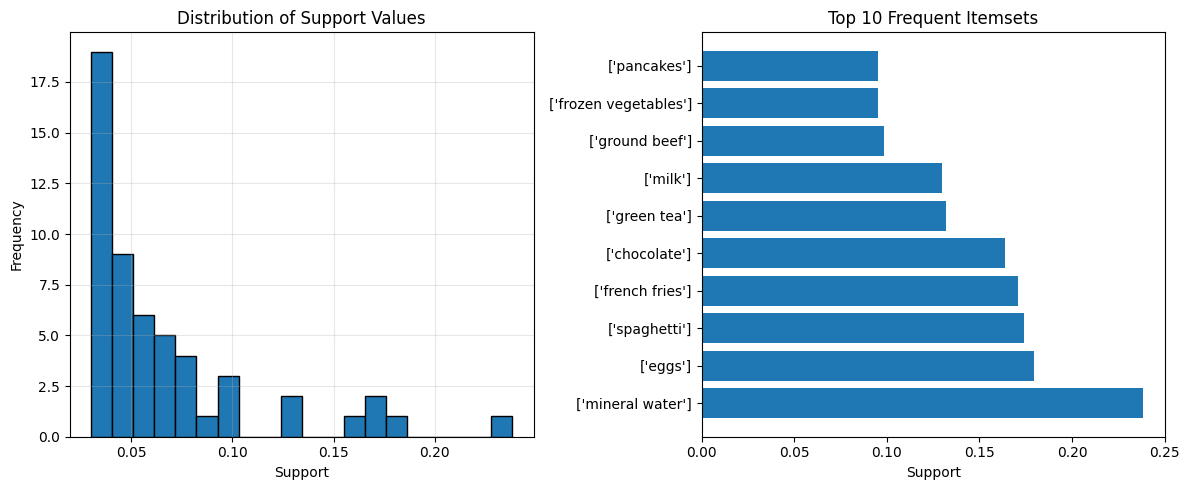

In [10]:
# Step 4: Apply Apriori Algorithm
# Set minimum support threshold (items should appear in at least 3% of transactions)
min_support = 0.03

# Apply Apriori algorithm
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

# Sort by support in descending order
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Number of Frequent Itemsets (min_support={min_support}): {len(frequent_itemsets)}")
print(f"\nTop 15 Frequent Itemsets:")
print(frequent_itemsets.head(15))

# Visualize support values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
frequent_itemsets['support'].hist(bins=20, edgecolor='black')
plt.xlabel('Support')
plt.ylabel('Frequency')
plt.title('Distribution of Support Values')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
top_items = frequent_itemsets.head(10)
plt.barh(range(len(top_items)), top_items['support'].values)
plt.yticks(range(len(top_items)), [str(list(x)) for x in top_items['itemsets'].values])
plt.xlabel('Support')
plt.title('Top 10 Frequent Itemsets')
plt.tight_layout()
plt.show()

In [11]:
# Step 5: Generate Association Rules
# Generate association rules with minimum confidence
min_confidence = 0.3

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# Calculate additional metrics
rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))

# Sort by lift in descending order (lift shows how much better the rule is than random chance)
rules = rules.sort_values('lift', ascending=False)

print(f"Number of Association Rules (min_confidence={min_confidence}): {len(rules)}")
print(f"\nTop 10 Association Rules (sorted by Lift):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# Show rules with high confidence and high lift
strong_rules = rules[(rules['confidence'] > 0.5) & (rules['lift'] > 1.2)]
print(f"\nStrong Rules (confidence > 0.5 and lift > 1.2): {len(strong_rules)}")
print(strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Number of Association Rules (min_confidence=0.3): 7

Top 10 Association Rules (sorted by Lift):
           antecedents      consequents   support  confidence      lift
4        (ground beef)      (spaghetti)  0.039195    0.398915  2.291162
3        (ground beef)  (mineral water)  0.040928    0.416554  1.747522
5  (frozen vegetables)  (mineral water)  0.035729    0.374825  1.572463
2               (milk)  (mineral water)  0.047994    0.370370  1.553774
6           (pancakes)  (mineral water)  0.033729    0.354839  1.488616
0          (spaghetti)  (mineral water)  0.059725    0.343032  1.439085
1          (chocolate)  (mineral water)  0.052660    0.321400  1.348332

Strong Rules (confidence > 0.5 and lift > 1.2): 0
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


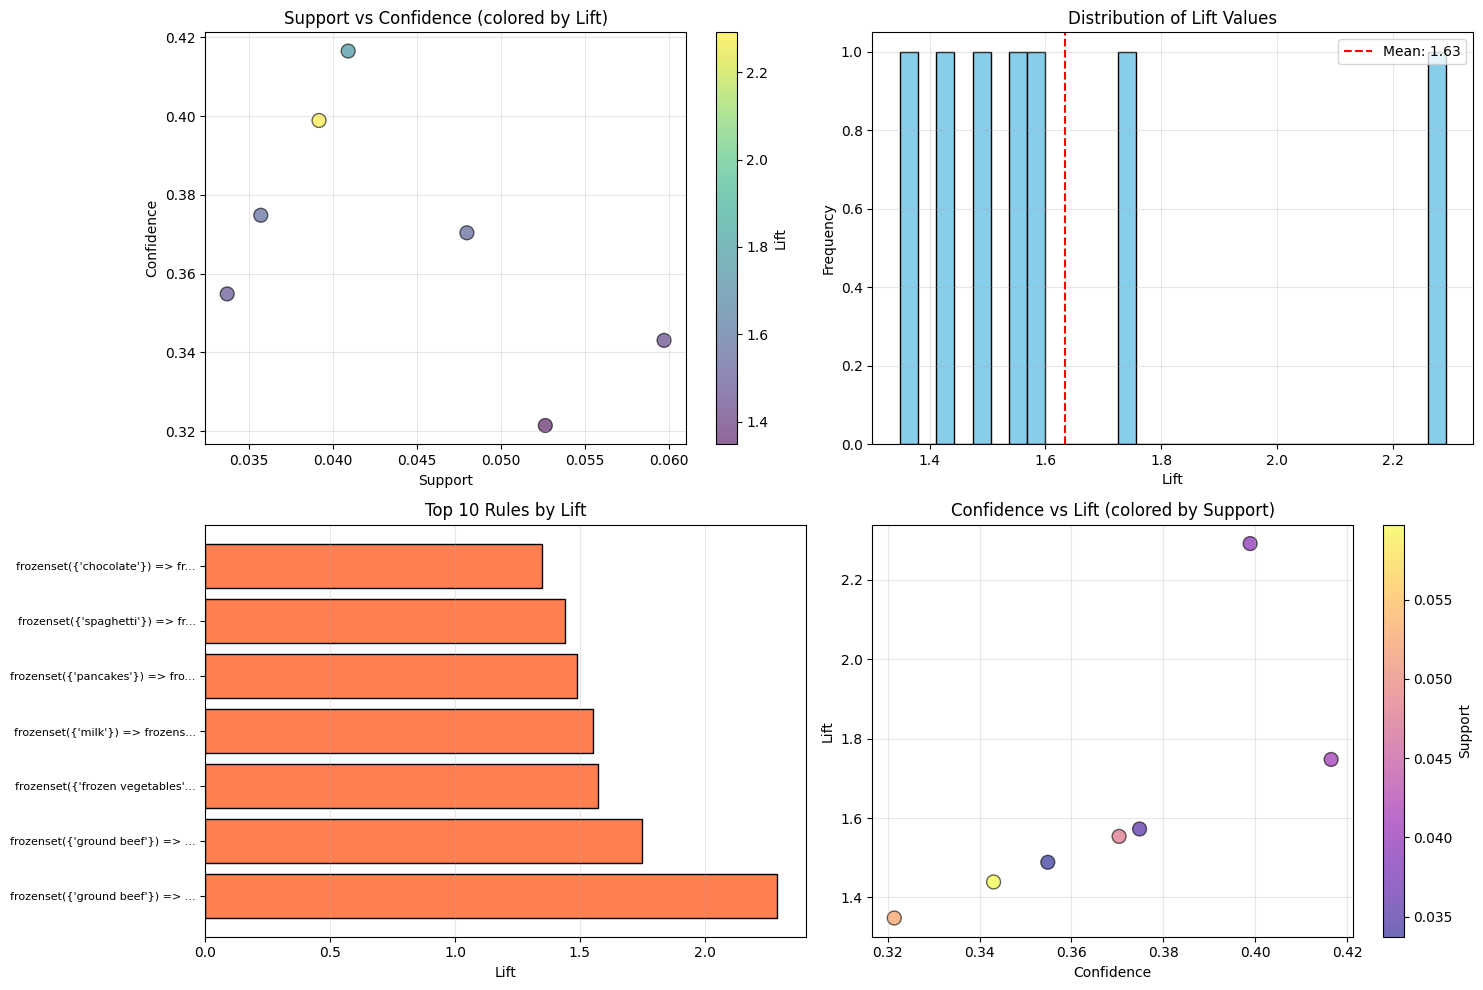


APRIORI ALGORITHM SUMMARY
Total Transactions: 7501
Total Unique Products: 120
Frequent Itemsets (support >= 0.03): 54
Association Rules (confidence >= 0.3): 7

Metrics Summary:
  Average Support: 0.0443
  Average Confidence: 0.3686
  Average Lift: 1.6344
  Max Lift: 2.2912


In [12]:
# Step 6: Visualize and Analyze Results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Support vs Confidence
ax1 = axes[0, 0]
scatter = ax1.scatter(rules['support'], rules['confidence'], c=rules['lift'], 
                       cmap='viridis', s=100, alpha=0.6, edgecolors='black')
ax1.set_xlabel('Support')
ax1.set_ylabel('Confidence')
ax1.set_title('Support vs Confidence (colored by Lift)')
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Lift')
ax1.grid(alpha=0.3)

# Plot 2: Lift Distribution
ax2 = axes[0, 1]
ax2.hist(rules['lift'], bins=30, edgecolor='black', color='skyblue')
ax2.axvline(rules['lift'].mean(), color='red', linestyle='--', label=f"Mean: {rules['lift'].mean():.2f}")
ax2.set_xlabel('Lift')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Lift Values')
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Top 10 Rules by Lift
ax3 = axes[1, 0]
top_rules = rules.head(10).copy()
top_rules['rule'] = top_rules['antecedents'].astype(str) + ' => ' + top_rules['consequents'].astype(str)
ax3.barh(range(len(top_rules)), top_rules['lift'].values, color='coral', edgecolor='black')
ax3.set_yticks(range(len(top_rules)))
ax3.set_yticklabels([r[:30] + '...' if len(r) > 30 else r for r in top_rules['rule'].values], fontsize=8)
ax3.set_xlabel('Lift')
ax3.set_title('Top 10 Rules by Lift')
ax3.grid(alpha=0.3, axis='x')

# Plot 4: Confidence vs Lift
ax4 = axes[1, 1]
scatter2 = ax4.scatter(rules['confidence'], rules['lift'], c=rules['support'], 
                        cmap='plasma', s=100, alpha=0.6, edgecolors='black')
ax4.set_xlabel('Confidence')
ax4.set_ylabel('Lift')
ax4.set_title('Confidence vs Lift (colored by Support)')
cbar2 = plt.colorbar(scatter2, ax=ax4)
cbar2.set_label('Support')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Statistics
print("\n" + "="*60)
print("APRIORI ALGORITHM SUMMARY")
print("="*60)
print(f"Total Transactions: {len(transactions)}")
print(f"Total Unique Products: {len(te.columns_)}")
print(f"Frequent Itemsets (support >= {min_support}): {len(frequent_itemsets)}")
print(f"Association Rules (confidence >= {min_confidence}): {len(rules)}")
print(f"\nMetrics Summary:")
print(f"  Average Support: {rules['support'].mean():.4f}")
print(f"  Average Confidence: {rules['confidence'].mean():.4f}")
print(f"  Average Lift: {rules['lift'].mean():.4f}")
print(f"  Max Lift: {rules['lift'].max():.4f}")
print("="*60)